In [70]:
#  Importa bibliotecas principais para análise e manipulação de dados
import pandas as pd       # Trabalhar com tabelas e datasets
import numpy as np        # Fazer cálculos numéricos e operações matemáticas
import matplotlib.pyplot as plt  # Criar gráficos básicos
import seaborn as sns     # Criar gráficos mais bonitos e detalhados

#  Importa ferramentas do scikit-learn para pré-processamento
from sklearn.impute import SimpleImputer          # Preenche valores faltantes (ex: média, mediana)
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # Padroniza números e transforma textos em números

#  Permite combinar diferentes transformações (numéricas e categóricas) em um único pipeline
from sklearn.compose import ColumnTransformer

#  Cria um pipeline que executa várias etapas automaticamente
from sklearn.pipeline import Pipeline

#  Usado para salvar objetos treinados (como scaler, encoder, modelos etc.)
import joblib


In [72]:
# 2️⃣ Carregamento de Dados  
df = pd.read_csv("./youtube_views.csv")
print("Formato:", df.shape)
df.head()

# Explicação: Nesta etapa, os dados do arquivo youtube_views.csv são carregados para o DataFrame e exibidos para uma verificação inicial.


Formato: (2520, 22)


,video_id,duration_minutes,title_length,description_length,tags_count,has_thumbnail_custom,video_quality,category,language,has_subtitles,channel_subscribers,channel_age_months,previous_videos_count,avg_upload_frequency_days,comments_count,likes_count,shares_count,playlist_adds,promoted,upload_time,upload_day,total_views
0,VID00197,3,53,589.0,34.0,Sim,720p,Fitness,Português,Não,474,NaN,406,9,2804.0,5269,NaN,624,Não,Tarde,Sexta,2219779
1,VID00987,60,95,NaN,17.0,Não,720p,Culinária,Português,Não,899904,NaN,25,14,9634.0,9448,1679.0,894,Sim,Tarde,Sexta,719904
2,VID01091,47,35,168.0,20.0,Não,1080p,Gaming,Espanhol,Não,761732,59.0,59,1,6943.0,34028,542.0,540,Não,Manhã,Seg-Qui,1420456
3,VID00388,8,12,260.0,4.0,Sim,1080p,Tecnologia,Português,Sim,154261,84.0,93,10,9427.0,42695,3096.0,188,Não,Madrugada,Sábado,329746
4,VID02222,56,94,648.0,48.0,Não,720p,Vlogs,Espanhol,Não,843352,6.0,205,13,2993.0,40761,311.0,957,Não,Manhã,Domingo,984985


                    Valores Faltantes  Percentual (%)
description_length                 40        1.587302
tags_count                         40        1.587302
channel_age_months                 40        1.587302
comments_count                     40        1.587302
shares_count                       40        1.587302


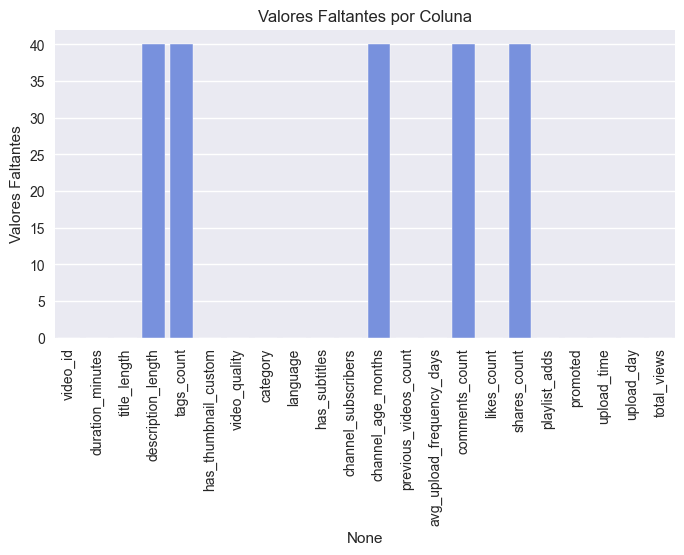

In [73]:
# 3️⃣ Análise de Valores Faltantes  
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_table = pd.DataFrame({"Valores Faltantes": missing, "Percentual (%)": missing_percent})
print(missing_table[missing_table["Valores Faltantes"] > 0])

plt.figure(figsize=(8,4))
sns.barplot(x=missing_table.index, y=missing_table["Valores Faltantes"])
plt.xticks(rotation=90)
plt.title("Valores Faltantes por Coluna")
plt.show()

# Explicação: Aqui identificamos quantos valores estão ausentes em cada coluna e mostramos um gráfico de barras para visualizar as colunas com mais dados faltantes.


In [74]:
# 4️⃣ Tratamento de Valores Faltantes  
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

imputer_num = SimpleImputer(strategy="median")  # Usa a mediana para preencher valores numéricos faltantes
imputer_cat = SimpleImputer(strategy="most_frequent")  # Usa o valor mais frequente para preencher categóricos

df[num_cols] = imputer_num.fit_transform(df[num_cols])
df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

print("Valores faltantes após imputação:", df.isnull().sum().sum())

# Explicação: Preenche os valores ausentes — números com a mediana e categorias com o valor mais comum.


Valores faltantes após imputação: 0


In [75]:
# 5️⃣ Remoção de Duplicatas  
print("Antes:", df.shape)
df = df.drop_duplicates()  # Remove linhas duplicadas no dataset
print("Depois:", df.shape)

# Explicação: Elimina registros repetidos para evitar distorções na análise.


Antes: (2520, 22)
Depois: (2520, 22)


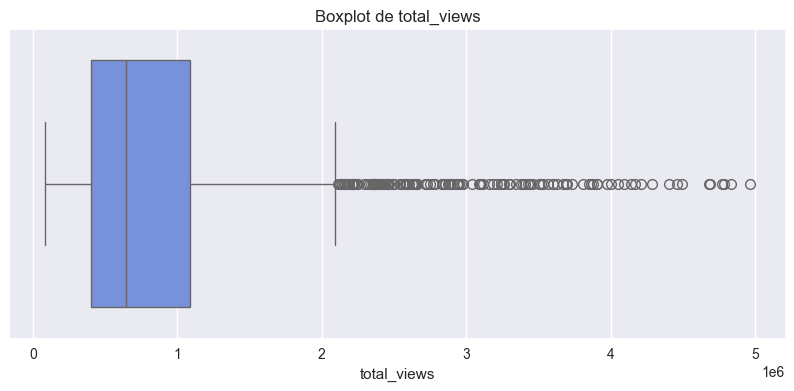

In [76]:
# 6️⃣ Identificação de Outliers  
col_exemplo = "total_views"  # Define a coluna que será analisada

plt.figure(figsize=(10,4))
sns.boxplot(x=df[col_exemplo])  # Exibe um boxplot para detectar valores fora do padrão
plt.title(f"Boxplot de {col_exemplo}")
plt.show()

# Explicação: O boxplot mostra possíveis outliers (valores extremos) na coluna escolhida.


In [78]:
# 7️⃣ Remoção de Outliers
Q1 = df[col_exemplo].quantile(0.25)   # Primeiro quartil (25%)
Q3 = df[col_exemplo].quantile(0.75)   # Terceiro quartil (75%)
IQR = Q3 - Q1                         # Intervalo interquartil (IQR)

# Define os limites inferior e superior para identificar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Mantém apenas os valores dentro do intervalo definido
df = df[(df[col_exemplo] >= limite_inferior) & (df[col_exemplo] <= limite_superior)]

print("Novo formato:", df.shape)

# Explicação: Remove valores extremos da coluna 'total_views' usando o método IQR,
# deixando apenas dados dentro de um intervalo considerado normal.


Novo formato: (2377, 22)


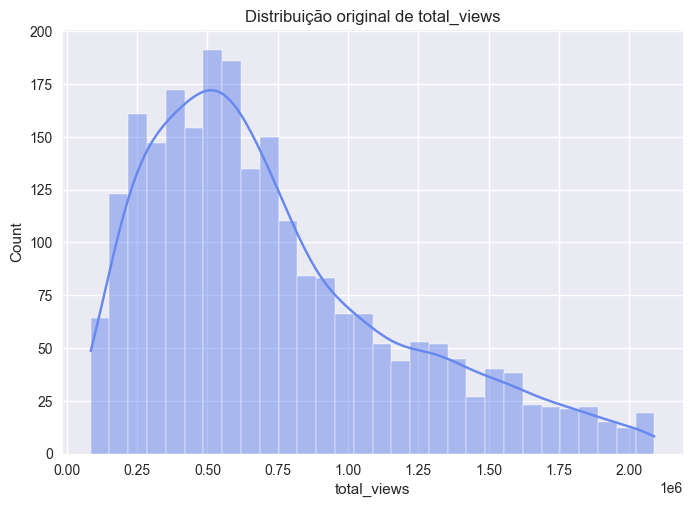

In [79]:
# 8️⃣ Verificação de Assimetria (Distribuição da Variável)
sns.histplot(df["total_views"], bins=30, kde=True)  # Cria um histograma com curva de densidade
plt.title("Distribuição original de total_views")
plt.show()

# Explicação: Mostra como os valores de 'total_views' estão distribuídos.
# Se a distribuição for muito inclinada (assimétrica), pode ser necessário aplicar uma transformação.


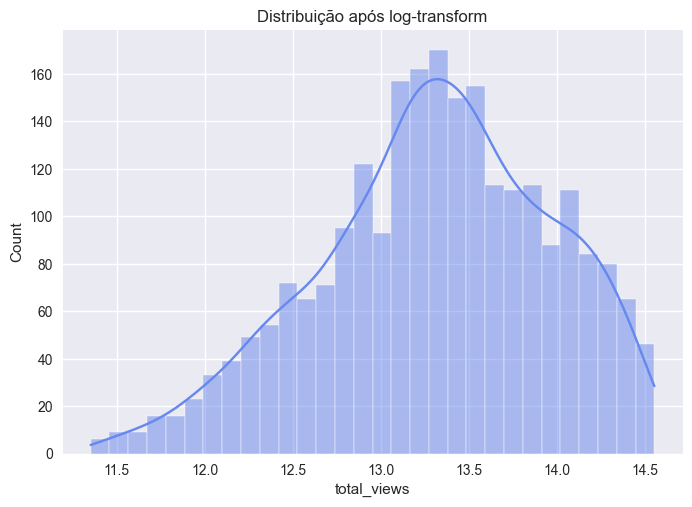

In [80]:
# 9️⃣ Transformação de Distribuição (Correção de Assimetria)
df["total_views"] = np.log1p(df["total_views"])  # Aplica log(1 + x) para reduzir a assimetria

sns.histplot(df["total_views"], bins=30, kde=True)  # Mostra a nova distribuição após transformação
plt.title("Distribuição após log-transform")
plt.show()

# Explicação: A transformação logarítmica deixa a distribuição mais próxima de uma curva normal,
# o que melhora o desempenho de modelos de machine learning.


In [81]:
# 🔟 Codificação de Variáveis Categóricas (One-Hot Encoding)
cat_cols = df.select_dtypes(exclude=np.number).columns  # Seleciona colunas categóricas

encoder = OneHotEncoder(drop="first", sparse_output=False)  # Cria o codificador (remove primeira categoria para evitar redundância)
encoded = pd.DataFrame(encoder.fit_transform(df[cat_cols]), columns=encoder.get_feature_names_out(cat_cols))  # Transforma categorias em variáveis numéricas

# Junta as novas colunas codificadas ao dataset original (removendo as originais categóricas)
df_encoded = pd.concat([df.drop(columns=cat_cols), encoded], axis=1)
df = df_encoded

# Explicação: Converte variáveis de texto (categóricas) em números,
# permitindo que o modelo de Machine Learning consiga interpretá-las corretamente.


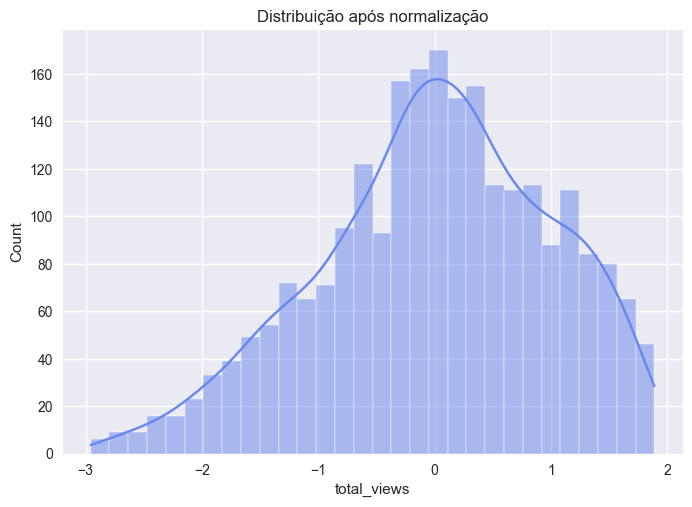

In [82]:
# 11️⃣ Normalização dos Dados Numéricos
scaler = StandardScaler()  # Cria o objeto para padronizar os dados
num_cols = df.select_dtypes(include=np.number).columns  # Seleciona apenas as colunas numéricas

# Aplica a padronização (média = 0, desvio padrão = 1)
df[num_cols] = scaler.fit_transform(df[num_cols])

# Exibe a distribuição da variável 'total_views' após normalização
sns.histplot(df["total_views"], bins=30, kde=True)
plt.title("Distribuição após normalização")
plt.show()

# Explicação: Padroniza os valores numéricos para que fiquem na mesma escala,
# evitando que variáveis com valores maiores influenciem mais o modelo.


In [88]:
# 12️⃣ Salvando o Dataset e o Scaler

import os

# Garante que a pasta 'models' existe
os.makedirs("models", exist_ok=True)

# Salva o dataset limpo
df.to_csv("./youtube_clean.csv", index=False)

# Salva o scaler para reutilizar na modelagem
joblib.dump(scaler, "models/scaler.pkl")

print("Dataset limpo salvo em data/youtube_clean.csv")
print("Scaler salvo em models/scaler.pkl")

# Explicação: cria a pasta se não existir e salva o dataset limpo e o objeto scaler para uso futuro.


Dataset limpo salvo em data/youtube_clean.csv
Scaler salvo em models/scaler.pkl


In [89]:
# 13️⃣ Conclusão da Etapa 2 - Pré-processamento de Dados

print("""
🧹 Conclusão — Etapa 2: Pré-processamento de Dados

Resumo do que foi feito:

• Valores faltantes tratados com SimpleImputer (média/moda conforme tipo da variável)
• Duplicatas removidas
• Outliers removidos com o método IQR
• Variáveis assimétricas corrigidas com np.log1p
• Categóricas transformadas com One-Hot Encoding
• Variáveis numéricas padronizadas com StandardScaler
• Dataset salvo como data/youtube_clean.csv
• Scaler salvo como models/scaler.pkl

✅ Dataset limpo e pronto para a Etapa 3 (Modelagem)
""")



🧹 Conclusão — Etapa 2: Pré-processamento de Dados

Resumo do que foi feito:

• Valores faltantes tratados com SimpleImputer (média/moda conforme tipo da variável)
• Duplicatas removidas
• Outliers removidos com o método IQR
• Variáveis assimétricas corrigidas com np.log1p
• Categóricas transformadas com One-Hot Encoding
• Variáveis numéricas padronizadas com StandardScaler
• Dataset salvo como data/youtube_clean.csv
• Scaler salvo como models/scaler.pkl

✅ Dataset limpo e pronto para a Etapa 3 (Modelagem)

